# Baseline Probe and (Stage 1) Fine-Tuning Analysis

This notebook analyzes the saved evaluation artifacts from two ways of adapting Aurora to out-of-distribution land-surface variables: a strict frozen linear probe and a LoRA fine-tuned model. The target variables are volumetric soil water in layer 1 (`swvl1`), soil temperature in layer 1 (`stl1`), and snow depth (`sd`), all predicted at a `t + 6h` horizon from ERA5-derived inputs.

The main question is whether Aurora’s pretrained latent representation already contains usable information about these variables, even though they were not part of the original prediction target set, and how much improvement comes from task-specific fine-tuning. The linear probe is the key diagnostic for this: because the encoder is frozen and only new decoder heads are trained, its performance measures what is linearly recoverable from the pretrained representation. The fine-tuned model, by contrast, measures how much the representation and readout can improve after limited adaptation on a small ERA5 snapshot.

We perform the analysis in five stages. First, we aggregate validation and test errors for the linear probe and compare it against the Stage 1 fine-tuned model. Second, we normalize errors and include two simple heuristic-based baselines (persistence and climatology) as reference floors to compare against and to understand how meaningful the error numbers are. This turns out to be important because persistence turns out to be unusually strong for a single 6-hour forecast for slow-changing land variables. Third, we examine spatial error maps to identify whether failures are geographically diffuse or concentrated. Fourth, we study temporal and hour-of-day structure, with special attention to the strong diurnal pattern in `stl1`. Finally, we use predicted-versus-truth scatter plots to evaluate calibration, dynamic-range compression, and whether validation and test behavior differ qualitatively.

In [23]:

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'results').exists():
    REPO_ROOT = REPO_ROOT.parent

LINEAR_PROBE_METRICS_PATH = REPO_ROOT / 'results' / 'linear_probe' / 'streaming_fit' / 'metrics.json'
LINEAR_PROBE_EVAL_PATH = REPO_ROOT / 'results' / 'linear_probe' / 'eval_20260506' / 'eval_summary.json'
STAGE1_SUMMARY_PATH = REPO_ROOT / 'results' / 'stage1_20260505_053645' / 'summary.json'
REFERENCE_BASELINE_DIR = REPO_ROOT / 'results' / 'reference_baselines'
PERSISTENCE_EVAL_PATH = REFERENCE_BASELINE_DIR / 'persistence' / 'eval_summary.json'
CLIMATOLOGY_EVAL_PATH = REFERENCE_BASELINE_DIR / 'climatology' / 'eval_summary.json'
FIGURE_DIR = REPO_ROOT / 'results' / 'linear_probe' / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

for path in [
    LINEAR_PROBE_METRICS_PATH,
    LINEAR_PROBE_EVAL_PATH,
    STAGE1_SUMMARY_PATH,
    PERSISTENCE_EVAL_PATH,
    CLIMATOLOGY_EVAL_PATH,
]:
    if not path.exists():
        raise FileNotFoundError(path)

with open(LINEAR_PROBE_METRICS_PATH) as f:
    linear_probe_fit = json.load(f)

with open(LINEAR_PROBE_EVAL_PATH) as f:
    linear_probe_eval = json.load(f)

with open(STAGE1_SUMMARY_PATH) as f:
    stage1_summary = json.load(f)

with open(PERSISTENCE_EVAL_PATH) as f:
    persistence_eval = json.load(f)

with open(CLIMATOLOGY_EVAL_PATH) as f:
    climatology_eval = json.load(f)

linear_probe_metrics = linear_probe_eval['metrics']
persistence_metrics = persistence_eval['metrics']
climatology_metrics = climatology_eval['metrics']
linear_probe_fit_stats = linear_probe_fit.get('fit_stats', {})

val_indices = [i for i, phase in enumerate(stage1_summary['phase']) if phase == 'val']
if not val_indices:
    raise ValueError('No validation checkpoints found in Stage 1 summary.')
stage1_val_idx = val_indices[-1]
stage1_val_metrics = {
    'swvl1': stage1_summary['mae_swvl1'][stage1_val_idx],
    'stl1': stage1_summary['mae_stl1'][stage1_val_idx],
    'sd': stage1_summary['mae_sd'][stage1_val_idx],
    'step': stage1_summary['step'][stage1_val_idx],
}

MODEL_COLORS = {
    'Linear Probe': '#2F6B8A',
    'Persistence': '#8B5E34',
    'Climatology': '#7C3AED',
    'Fine-Tuned Stage 1': '#2E8B57',
}

print('Repo root:', REPO_ROOT)
print('Linear probe train samples seen:', linear_probe_fit_stats.get('train_samples_seen'))
print('Linear probe eval summary:', linear_probe_metrics)
print('Persistence eval summary:', persistence_metrics)
print('Climatology eval summary:', climatology_metrics)
print('Stage 1 validation step:', stage1_val_metrics['step'])


Repo root: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project
Linear probe train samples seen: 1416
Linear probe eval summary: {'val_samples': 708, 'val_swvl1_mae': 0.06464769116649569, 'val_swvl1_rmse': 0.08328932572585111, 'val_stl1_mae': 2.7153835815157747, 'val_stl1_rmse': 3.604579479131024, 'val_sd_mae': 0.5409512839545471, 'val_sd_rmse': 0.9021594203902008, 'test_samples': 756, 'test_swvl1_mae': 0.06767174639348185, 'test_swvl1_rmse': 0.08661885634433007, 'test_stl1_mae': 2.930501023272387, 'test_stl1_rmse': 3.819302281522358, 'test_sd_mae': 0.5510097821960551, 'test_sd_rmse': 0.914339567140719}
Persistence eval summary: {'val_samples': 708, 'val_swvl1_mae': 0.0038727981919127533, 'val_swvl1_rmse': 0.01010503610252466, 'val_stl1_mae': 2.786571270369206, 'val_stl1_rmse': 4.501285612880297, 'val_sd_mae': 1.3656656795745232e-05, 'val_sd_rmse': 0.00021537180450054868, 'test_samples': 756, 'test_swvl1_mae': 0.0037598170952257786, 'test_swvl1_rmse': 0.009989550785054474, 

## 1. Aggregate Linear-Probe Performance

We begin with the aggregate MAE and RMSE from the frozen linear-probe evaluation. These metrics summarize performance over all land pixels and all target times in the validation and test windows. The purpose of this section is not to compare `swvl1`, `stl1`, and `sd` directly against each other, since their units and scales are different, but to check whether the probe behaves similarly on validation and test for each variable. 

The two figures here are also the only ones in the notebook that we expect to read in native units. Everything afterward will switch to a normalized view so the three variables can be compared on the same scale.

This is the first sanity check for the baseline. If validation and test errors were very different, the rest of the analysis would mostly be about split instability. As it turns out, the validation and test bars are close for all three variables, with test slightly worse. We then shift to understanding  what kind of information the frozen representation exposes, and where that representation remains insufficient.

In [24]:
variables = ['swvl1', 'stl1', 'sd']
metric_rows = []

for split in ['val', 'test']:
    for variable in variables:
        metric_rows.append({
            'split': split,
            'variable': variable,
            'MAE': linear_probe_metrics[f'{split}_{variable}_mae'],
            'RMSE': linear_probe_metrics[f'{split}_{variable}_rmse'],
        })

headline_df = pd.DataFrame(metric_rows)
headline_df


,split,variable,MAE,RMSE
0,val,swvl1,0.064648,0.083289
1,val,stl1,2.715384,3.604579
2,val,sd,0.540951,0.902159
3,test,swvl1,0.067672,0.086619
4,test,stl1,2.930501,3.819302
5,test,sd,0.551010,0.914340


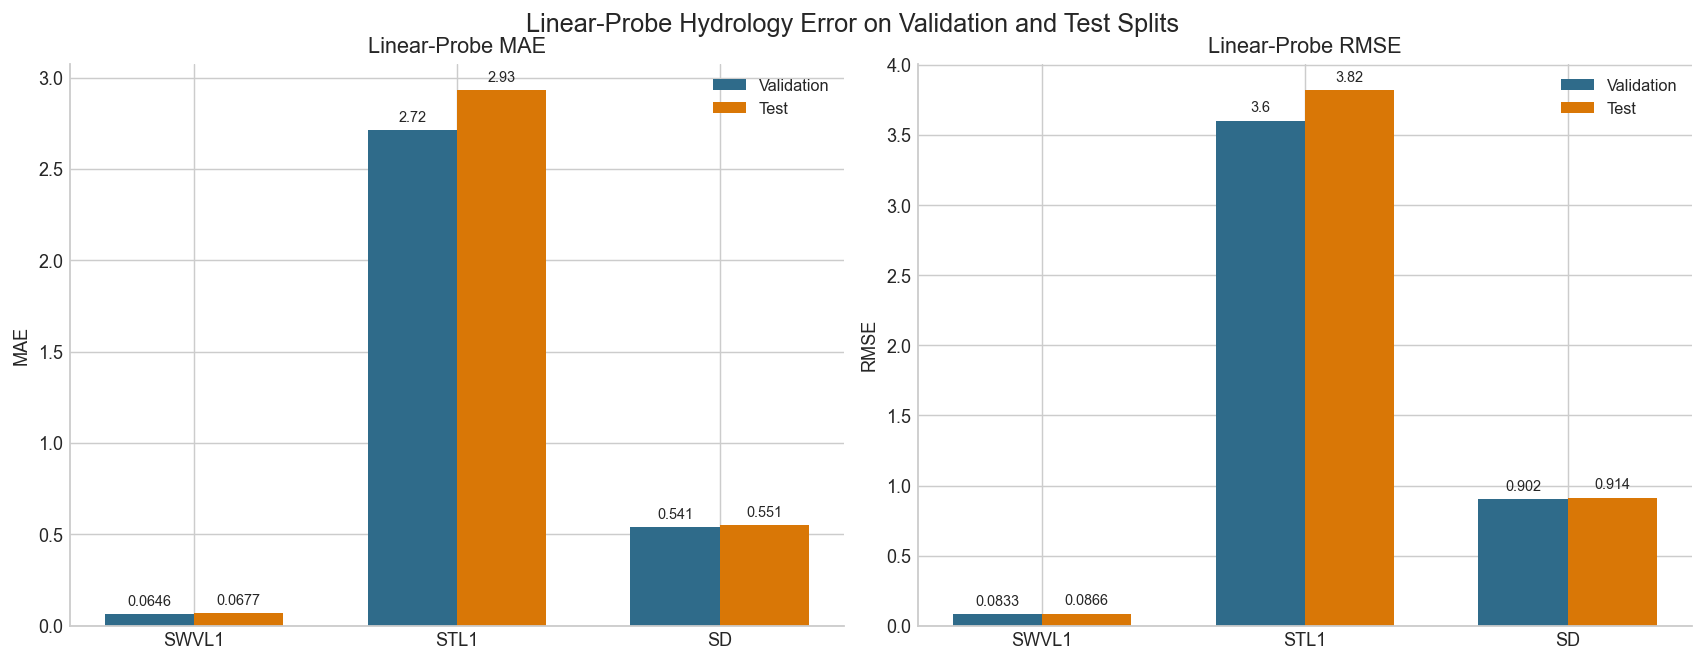

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/headline_linear_probe_mae_rmse.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
series = [
    ('val', MODEL_COLORS['Linear Probe'], 'Validation'),
    ('test', '#D97706', 'Test'),
]
x = np.arange(len(variables))
width = 0.34
offsets = [-width / 2, width / 2]

for ax, metric_name in zip(axes, ['MAE', 'RMSE']):
    for offset, (split, color, label) in zip(offsets, series):
        values = [
            headline_df.loc[
                (headline_df['split'] == split) & (headline_df['variable'] == variable),
                metric_name,
            ].iloc[0]
            for variable in variables
        ]
        bars = ax.bar(x + offset, values, width=width, label=label, color=color)
        ax.bar_label(bars, fmt='%.3g', padding=3, fontsize=8)

    ax.set_title(f'Linear-Probe {metric_name}')
    ax.set_xticks(x)
    ax.set_xticklabels([v.upper() for v in variables])
    ax.set_ylabel(metric_name)
    ax.legend(frameon=False, fontsize=9)

fig.suptitle('Linear-Probe Hydrology Error on Validation and Test Splits', fontsize=14, y=1.03)
save_path = FIGURE_DIR / 'headline_linear_probe_mae_rmse.png'
fig.savefig(save_path, bbox_inches='tight')
plt.show()
print('Saved:', save_path)


**Figure 1. Aggregate linear-probe MAE and RMSE on validation and test splits.** Errors are pooled over land pixels and target times for each variable. Validation and test errors are close for all three targets, which suggests that the frozen linear probe transfers reasonably consistently across the two July evaluation windows.

Because the targets have different physical units, this figure should be read **within-variable** rather than as a cross-variable difficulty ranking.

In [26]:
comparison_df = pd.DataFrame({
    'variable': variables,
    'linear_probe_val_mae': [linear_probe_metrics[f'val_{variable}_mae'] for variable in variables],
    'finetuned_val_mae': [stage1_val_metrics[variable] for variable in variables],
})
comparison_df['finetune_vs_lp_factor'] = comparison_df['linear_probe_val_mae'] / comparison_df['finetuned_val_mae']
comparison_df


,variable,linear_probe_val_mae,finetuned_val_mae,finetune_vs_lp_factor
0,swvl1,0.064648,0.012459,5.188973
1,stl1,2.715384,1.050773,2.584178
2,sd,0.540951,0.132759,4.074693


After establishing that the linear probe is stable across splits, we compare it with the Stage 1 LoRA fine-tuned model on the validation split. This comparison asks a different question: not whether the frozen representation contains any signal, but whether task-specific adaptation can substantially improve over a purely linear readout. A large gap here means that the frozen Aurora latent is useful but not sufficient; the model benefits from adapting its representation or decoder pathway to the new hydrology targets.

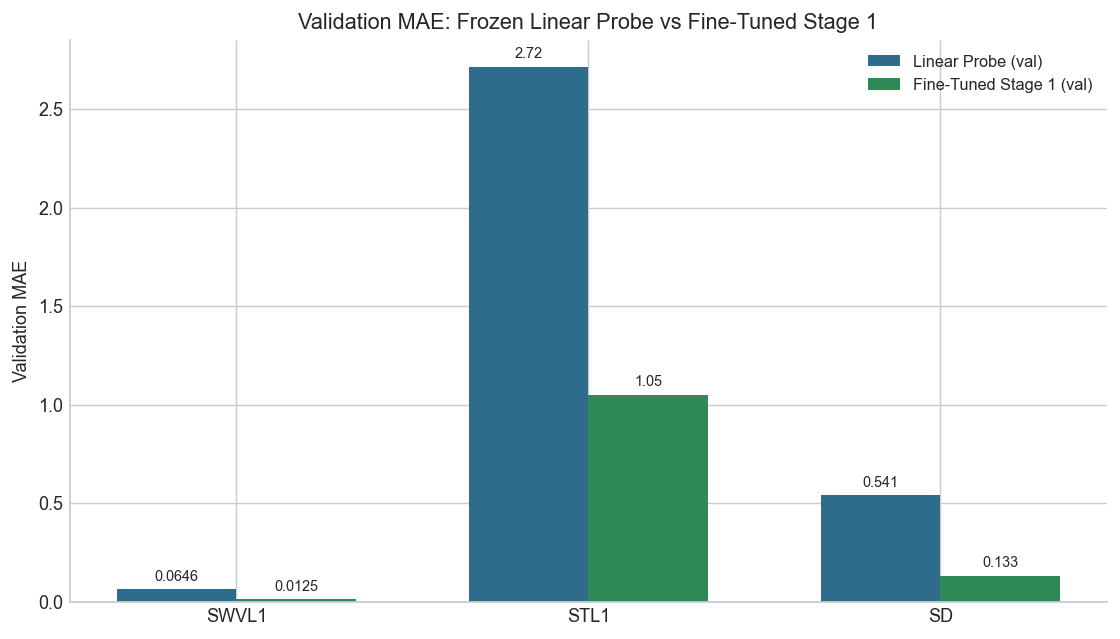

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/validation_mae_linear_probe_vs_finetuned.png


In [27]:
fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)
x = np.arange(len(variables))
width = 0.34
series = [
    ('linear_probe_val_mae', 'Linear Probe (val)', MODEL_COLORS['Linear Probe']),
    ('finetuned_val_mae', 'Fine-Tuned Stage 1 (val)', MODEL_COLORS['Fine-Tuned Stage 1']),
]
offsets = [-width / 2, width / 2]

for offset, (column, label, color) in zip(offsets, series):
    vals = comparison_df[column].to_numpy()
    bars = ax.bar(x + offset, vals, width=width, label=label, color=color)
    ax.bar_label(bars, fmt='%.3g', padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([v.upper() for v in variables])
ax.set_ylabel('Validation MAE')
ax.set_title('Validation MAE: Frozen Linear Probe vs Fine-Tuned Stage 1')
ax.legend(frameon=False, fontsize=9)

save_path = FIGURE_DIR / 'validation_mae_linear_probe_vs_finetuned.png'
fig.savefig(save_path, bbox_inches='tight')
plt.show()
print('Saved:', save_path)


**Figure 2. Validation MAE for the frozen linear probe vs Stage 1 fine-tuned model.** The fine-tuned model improves substantially for all three variables, with the largest relative gains for `swvl1` and `sd`.

This supports the interpretation that Aurora’s pretrained representation contains recoverable land-surface information, but that the strict linear readout leaves substantial performance on the table.

A caveat to note here is that in Figure 2, `STL1` errors are reported in Kelvin and `SWVL1` errors in volumetric fraction, so the bar heights are not on the same scale.

## 2. Reference Baseline Check via Normalized Error

The raw MAE values above cannot be compared directly across variables because `swvl1`, `stl1`, and `sd` have different units and natural scales. To make the errors more comparable, this section reports normalized MAE, computed as `MAE / σ_train`, where `σ_train` is the Stage 1 training-set standard deviation used for target normalization.

This section also adds two non-neural reference baselines: persistence and climatology. These baselines are essential for interpreting a `t + 6h` forecast. Persistence predicts that the variable will remain close to its current value, which is a very strong assumption for slowly evolving land variables over only six hours. Climatology ignores the current state and instead uses the average value of the variable over hourly buckets for prediction. Hence, persistence beating the learned models on `swvl1` or summer `sd`, that should not be read as evidence that persistence is a "better" hydrology model, but rather that single-step evaluation horizon rewards short-term inertia.

One caveat is that the plotted fine-tuned Stage 1 value is from validation, while the linear probe and reference baselines are shown on test.

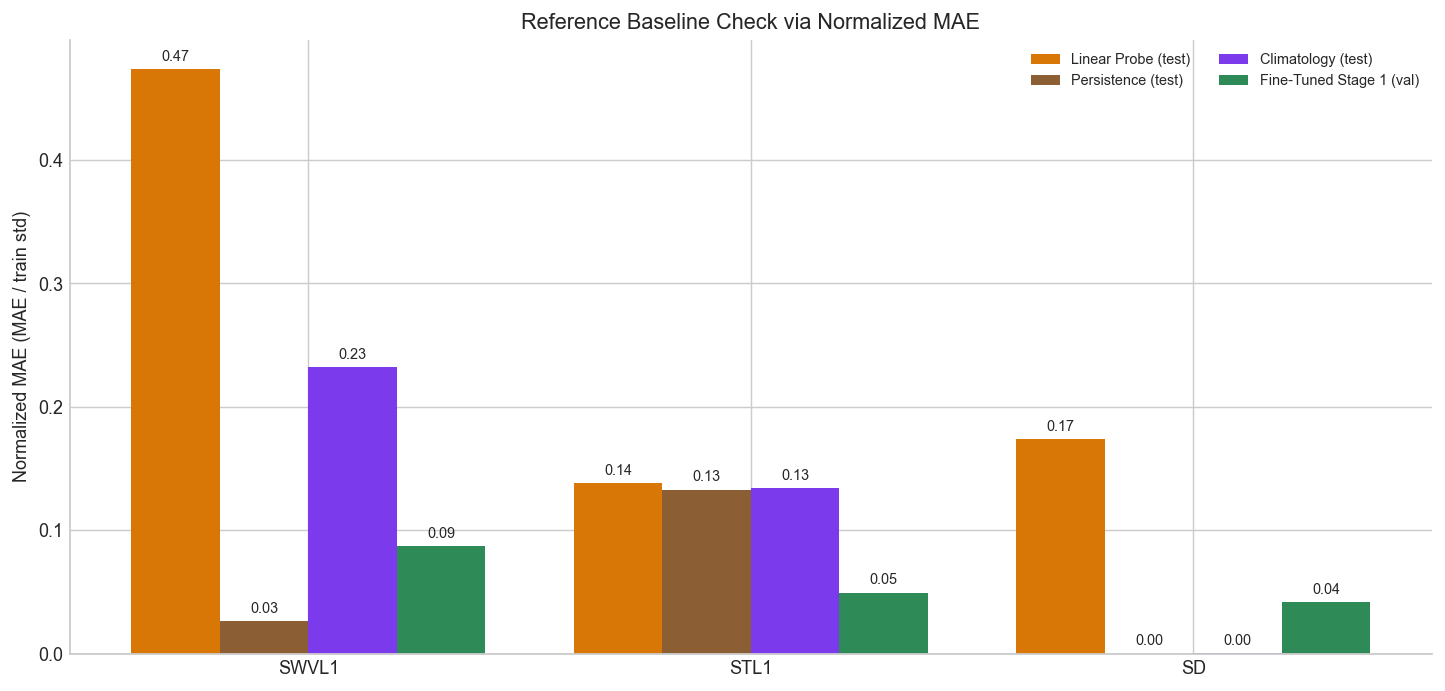

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/reference_baseline_normalized_mae.png


In [28]:
TRAIN_STDS = {'swvl1': 1.428390e-01, 'stl1': 2.123255e+01, 'sd': 3.172587e+00}

baseline_comparison_df = pd.DataFrame({
    'variable': variables,
    'linear_probe_test_nmae': [linear_probe_metrics[f'test_{v}_mae'] / TRAIN_STDS[v] for v in variables],
    'persistence_test_nmae': [persistence_metrics[f'test_{v}_mae'] / TRAIN_STDS[v] for v in variables],
    'climatology_test_nmae': [climatology_metrics[f'test_{v}_mae'] / TRAIN_STDS[v] for v in variables],
    'finetuned_val_nmae': [stage1_val_metrics[v] / TRAIN_STDS[v] for v in variables],
})
baseline_comparison_df

fig, ax = plt.subplots(figsize=(11, 5.2), constrained_layout=True)
x = np.arange(len(variables))
width = 0.20
series = [
    ('linear_probe_test_nmae', 'Linear Probe (test)', '#D97706'),
    ('persistence_test_nmae', 'Persistence (test)', MODEL_COLORS['Persistence']),
    ('climatology_test_nmae', 'Climatology (test)', MODEL_COLORS['Climatology']),
    ('finetuned_val_nmae', 'Fine-Tuned Stage 1 (val)', MODEL_COLORS['Fine-Tuned Stage 1']),
]
offsets = np.linspace(-1.5 * width, 1.5 * width, len(series))
for offset, (column, label, color) in zip(offsets, series):
    bars = ax.bar(x + offset, baseline_comparison_df[column], width=width, label=label, color=color)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([v.upper() for v in variables])
ax.set_ylabel('Normalized MAE (MAE / train std)')
ax.set_title('Reference Baseline Check via Normalized MAE')
ax.legend(frameon=False, fontsize=8, ncol=2)
save_path = FIGURE_DIR / 'reference_baseline_normalized_mae.png'
fig.savefig(save_path, bbox_inches='tight')
plt.show()
print('Saved:', save_path)


**Figure 3. Normalized MAE for the linear probe, persistence, climatology, and Stage 1 fine-tuning.** Normalization makes the three targets comparable on a shared scale.

The linear probe is weakest on `swvl1`, much stronger on `stl1`, and intermediate on `sd`. Persistence is extremely strong for `swvl1` and `sd`, which is expected for a short `t + 6h` horizon where these variables often change little. 
For `stl1`, persistence, climatology, and the linear probe are much closer, making soil temperature the most interesting target for a temporal error analysis rather than just an aggregate comparison.

The rest of the notebook is organized around these three observations: where exactly does the linear probe fail (Section 3), when does it fail (Section 4), and how does it fail (Section 7). Sections 5 and 6 are the diagnostic detour the STL1 diurnal cycle forces us to take.

## 3. Spatial Error Structure

The aggregate metrics show how large the errors are on average, but they do not show whether those errors are geographically uniform. This section uses the saved per-pixel spatial aggregates from the linear-probe evaluation: mean absolute error and mean signed error over the validation and test windows. All maps are restricted to evaluated land pixels under the same masking used in the main baseline run.

The purpose here is to separate *overall* performance from *regional* performance. Our model could have a reasonable global MAE while still carrying strong geographic bias, so these maps show whether the linear probe's errors are diffuse, localized, or systematically signed in specific regions.

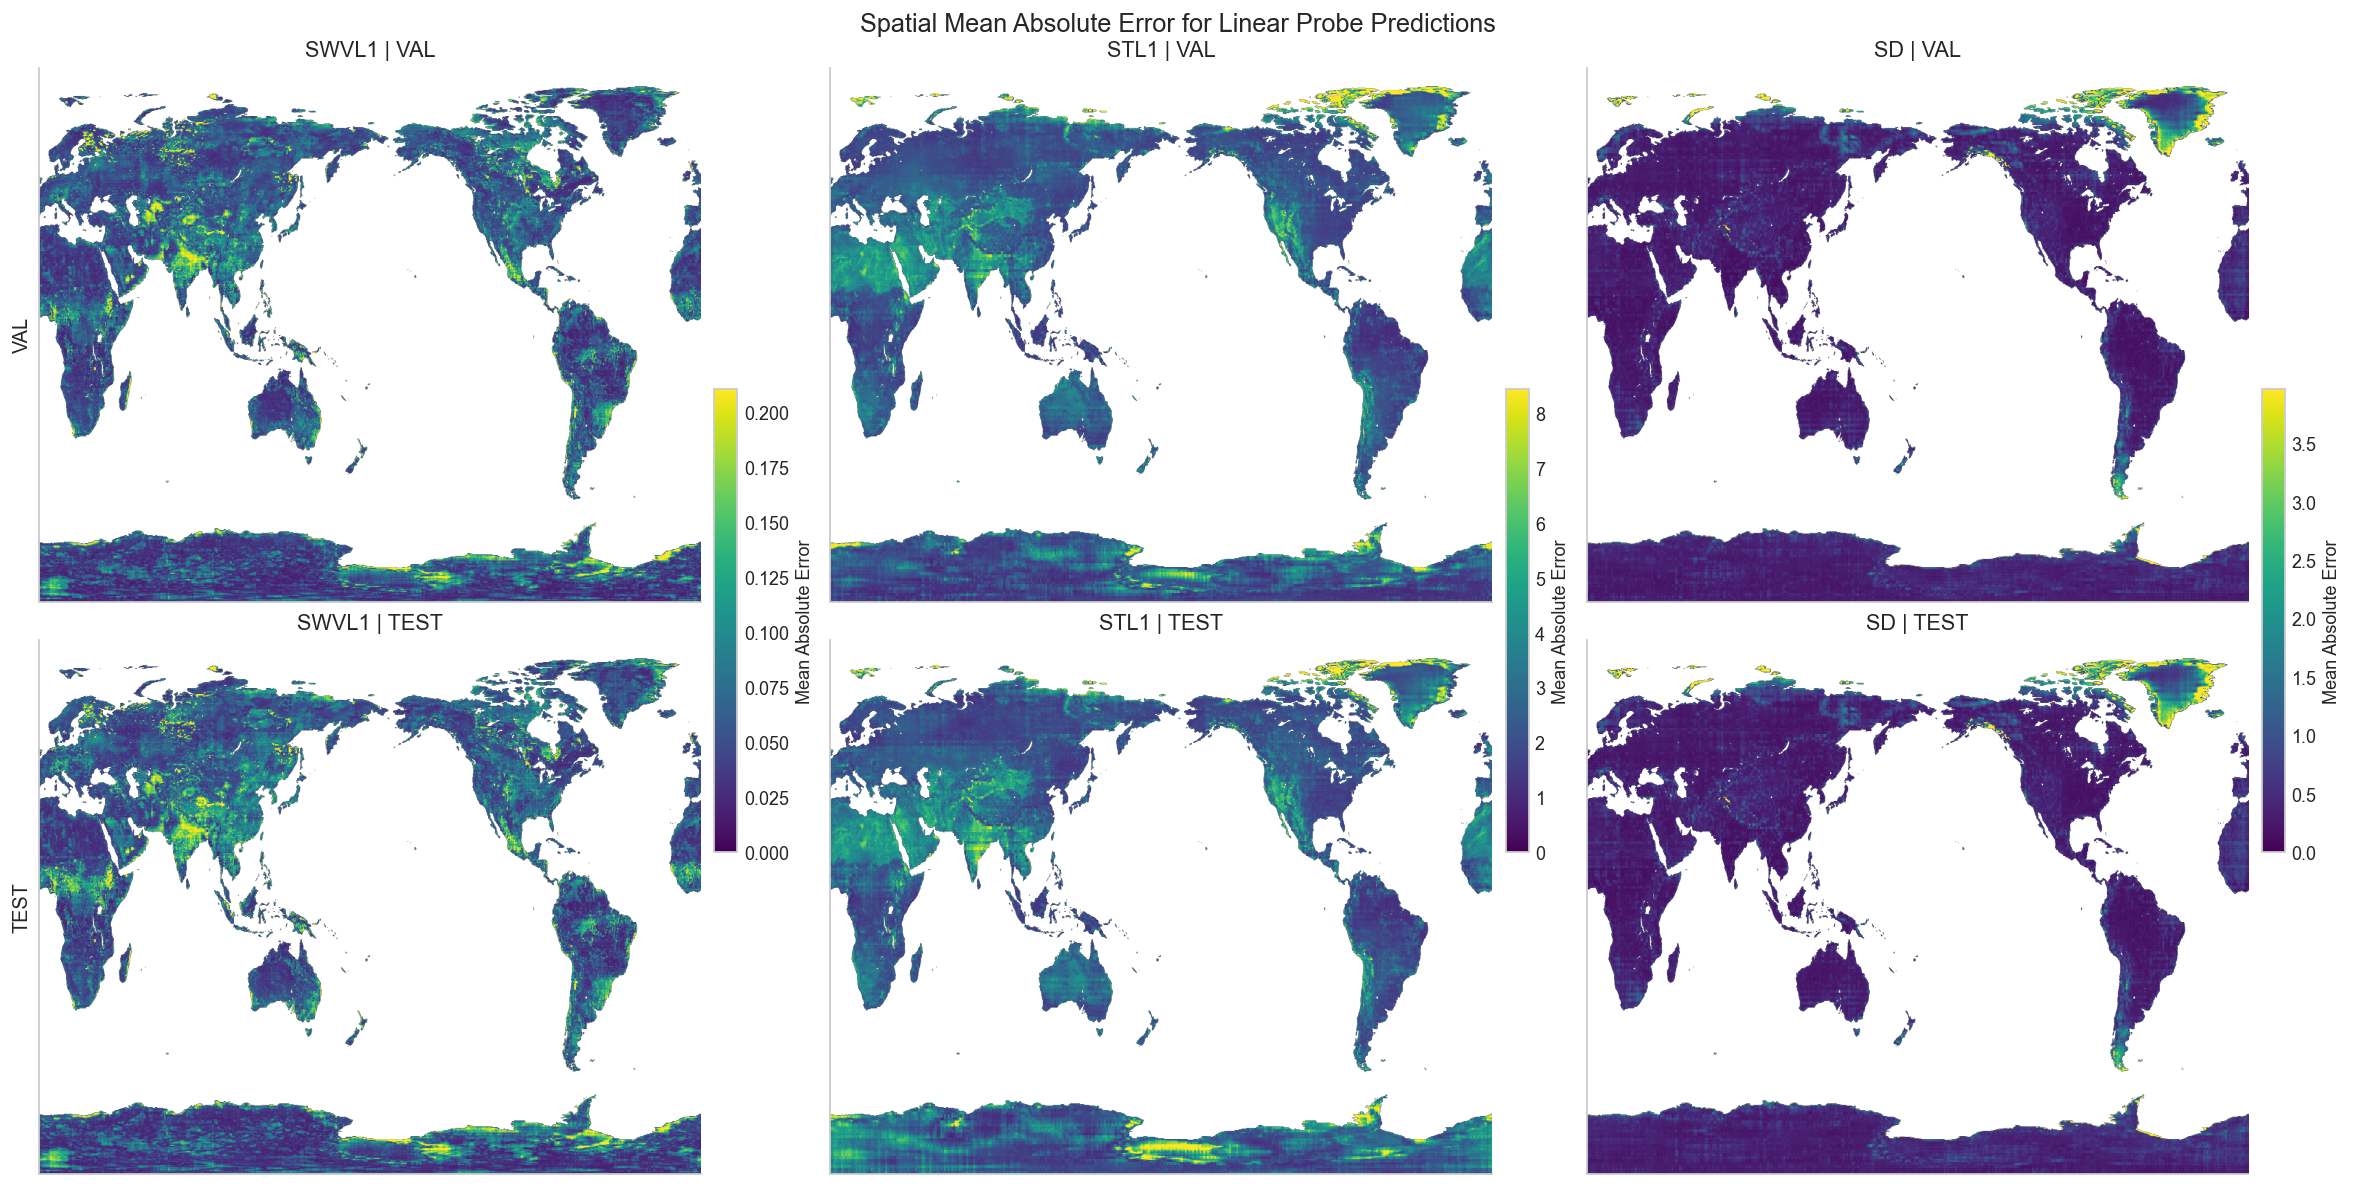

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/spatial_mean_abs_err.png


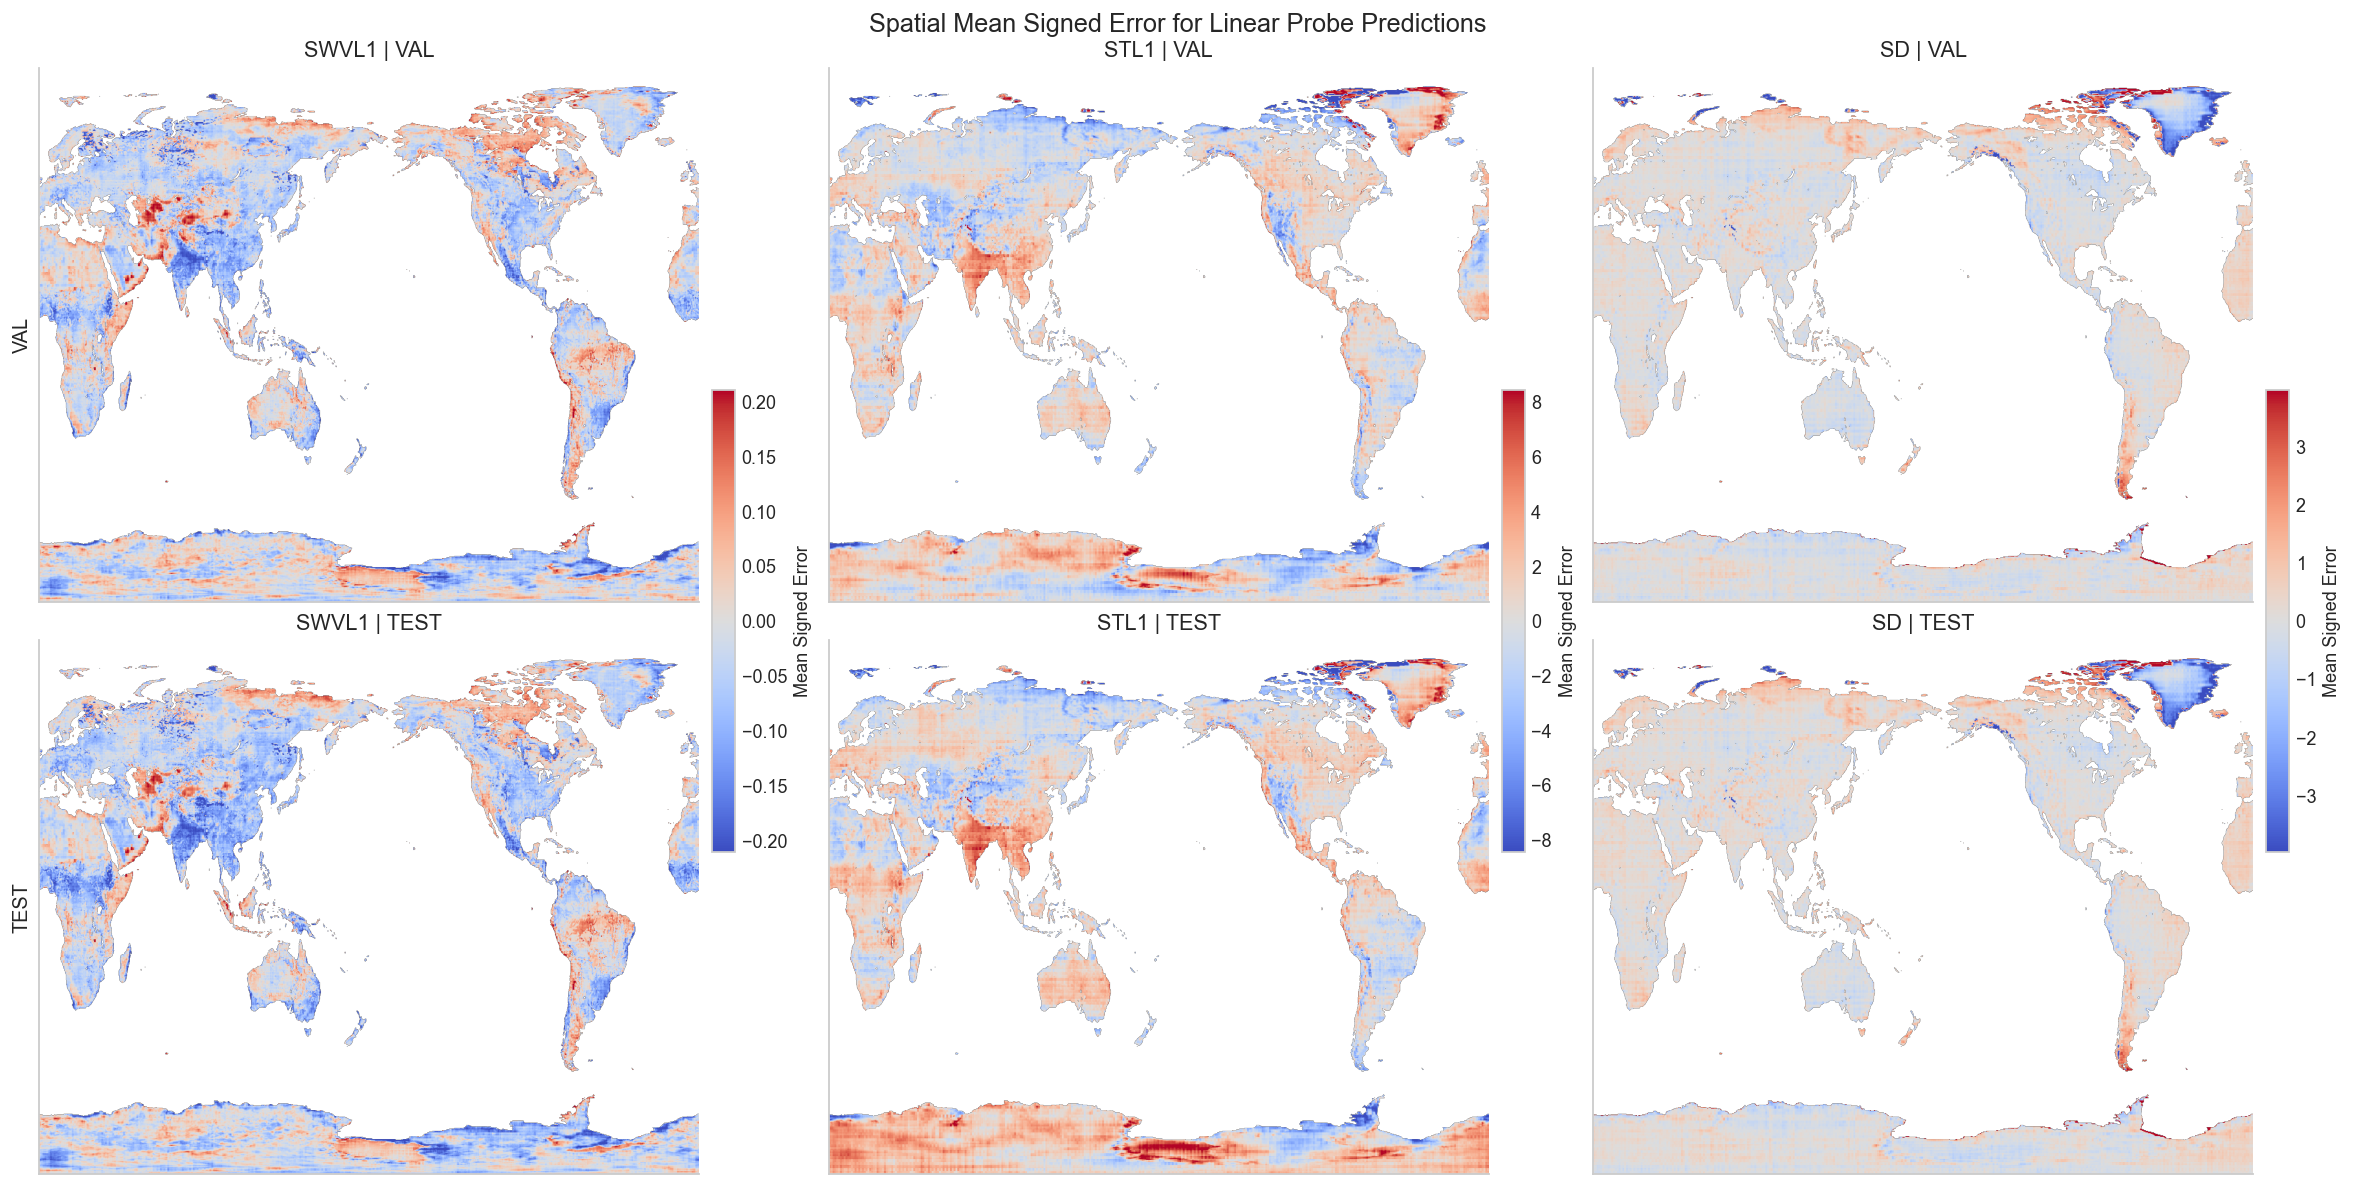

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/spatial_mean_signed_err.png


In [29]:
SPATIAL_DIR = REPO_ROOT / 'results' / 'linear_probe' / 'eval_20260506' / 'spatial_aggregates'

count_maps = {
    split: np.load(SPATIAL_DIR / f'{split}_count.npy')
    for split in ['val', 'test']
}

spatial_metrics = {}
for split in ['val', 'test']:
    spatial_metrics[split] = {}
    for variable in variables:
        spatial_metrics[split][variable] = {
            'mean_abs_err': np.load(SPATIAL_DIR / f'{split}_{variable}_mean_abs_err.npy'),
            'mean_signed_err': np.load(SPATIAL_DIR / f'{split}_{variable}_mean_signed_err.npy'),
            'rmse': np.load(SPATIAL_DIR / f'{split}_{variable}_rmse.npy'),
        }

def masked_land_map(array, split):
    return np.ma.masked_where(count_maps[split] <= 0, array)

def finite_values(masked_array):
    return masked_array.compressed()

pretty_names = {'swvl1': 'SWVL1', 'stl1': 'STL1', 'sd': 'SD'}

for metric_key, title, cmap, symmetric in [
    ('mean_abs_err', 'Mean Absolute Error', 'viridis', False),
    ('mean_signed_err', 'Mean Signed Error', 'coolwarm', True),
]:
    fig, axes = plt.subplots(2, 3, figsize=(18, 8.8), constrained_layout=True)
    for col, variable in enumerate(variables):
        maps = {
            split: masked_land_map(spatial_metrics[split][variable][metric_key], split)
            for split in ['val', 'test']
        }

        if symmetric:
            vmax = max(
                float(np.quantile(np.abs(finite_values(maps['val'])), 0.99)),
                float(np.quantile(np.abs(finite_values(maps['test'])), 0.99)),
            )
            vmin = -vmax
        else:
            vmax = max(
                float(np.quantile(finite_values(maps['val']), 0.99)),
                float(np.quantile(finite_values(maps['test']), 0.99)),
            )
            vmin = 0.0

        for row, split in enumerate(['val', 'test']):
            ax = axes[row, col]
            im = ax.imshow(maps[split], cmap=cmap, origin='upper', vmin=vmin, vmax=vmax, aspect='auto')
            ax.set_title(f"{pretty_names[variable]} | {split.upper()}")
            ax.set_xticks([])
            ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(split.upper(), fontsize=11)

        cbar = fig.colorbar(im, ax=axes[:, col], fraction=0.035, pad=0.02)
        cbar.ax.set_ylabel(title, rotation=90)

    fig.suptitle(f'Spatial {title} for Linear Probe Predictions', fontsize=14, y=1.02)
    save_path = FIGURE_DIR / f'spatial_{metric_key}.png'
    fig.savefig(save_path, bbox_inches='tight')
    plt.show()
    print('Saved:', save_path)


**Figure 4a. Spatial mean absolute error and Figure 4b. spatial mean signed error for the linear probe.** Both figures are built from the saved per-pixel spatial aggregates over land. T

he absolute-error maps localize where the baseline is weakest; the signed-error maps reveal coherent geographic bias. Together they show that the probe's failures are structured in space, not just random noise. One thing to note is that the RMSE maps describe a *typical pixel*, whereas the headline RMSE bars describe the *pooled overall* error.

### Spatial Observations

The spatial maps show that the linear probe’s errors are not uniformly distributed across land. For `swvl1`, elevated absolute error appears across broad humid, high-latitude, and topographically complex regions rather than in one isolated hotspot. This supports the aggregate result that soil moisture is the hardest of the three targets for a frozen linear readout.

For `stl1`, the absolute errors are lower relative to the variable’s scale, but the signed-error maps show coherent regional structure. This suggests that soil temperature is strongly encoded in the frozen representation, but the linear head does not perfectly calibrate the relationship everywhere. The issue is less “the model cannot see soil temperature” and more “the linear readout cannot fully correct regional biases.”

For `sd`, the spatial pattern is sparse and regime-dependent. Most land pixels have very small error in July, while the larger errors are concentrated in snow-sensitive regions such as Greenland, high mountains, and polar-adjacent areas. This is important because snow depth is not uniformly difficult; its difficulty is concentrated in the subset of pixels where snow is physically present or where the target distribution has a heavy tail.

Across variables, validation and test spatial patterns look similar. That consistency strengthens the interpretation that the remaining errors are representational or calibration limits of the frozen probe, rather than random artifacts of a particular evaluation split.

## 4. Error Over Time

After identifying where the linear probe makes errors, we next ask when those errors occur. This section uses the per-sample metrics file, where each row corresponds to one `(split, timestamp, variable)` evaluation point with land-aggregated MAE, RMSE, and signed error. The curves are separated by year because the evaluation consists of July windows from 2024 and 2025 rather than one continuous time series.

The purpose of these plots is to reveal reveal whether the probe degrades smoothly through time, whether test errors jump sharply relative to validation, and whether any variable shows repeated temporal structure that deserves closer inspection.

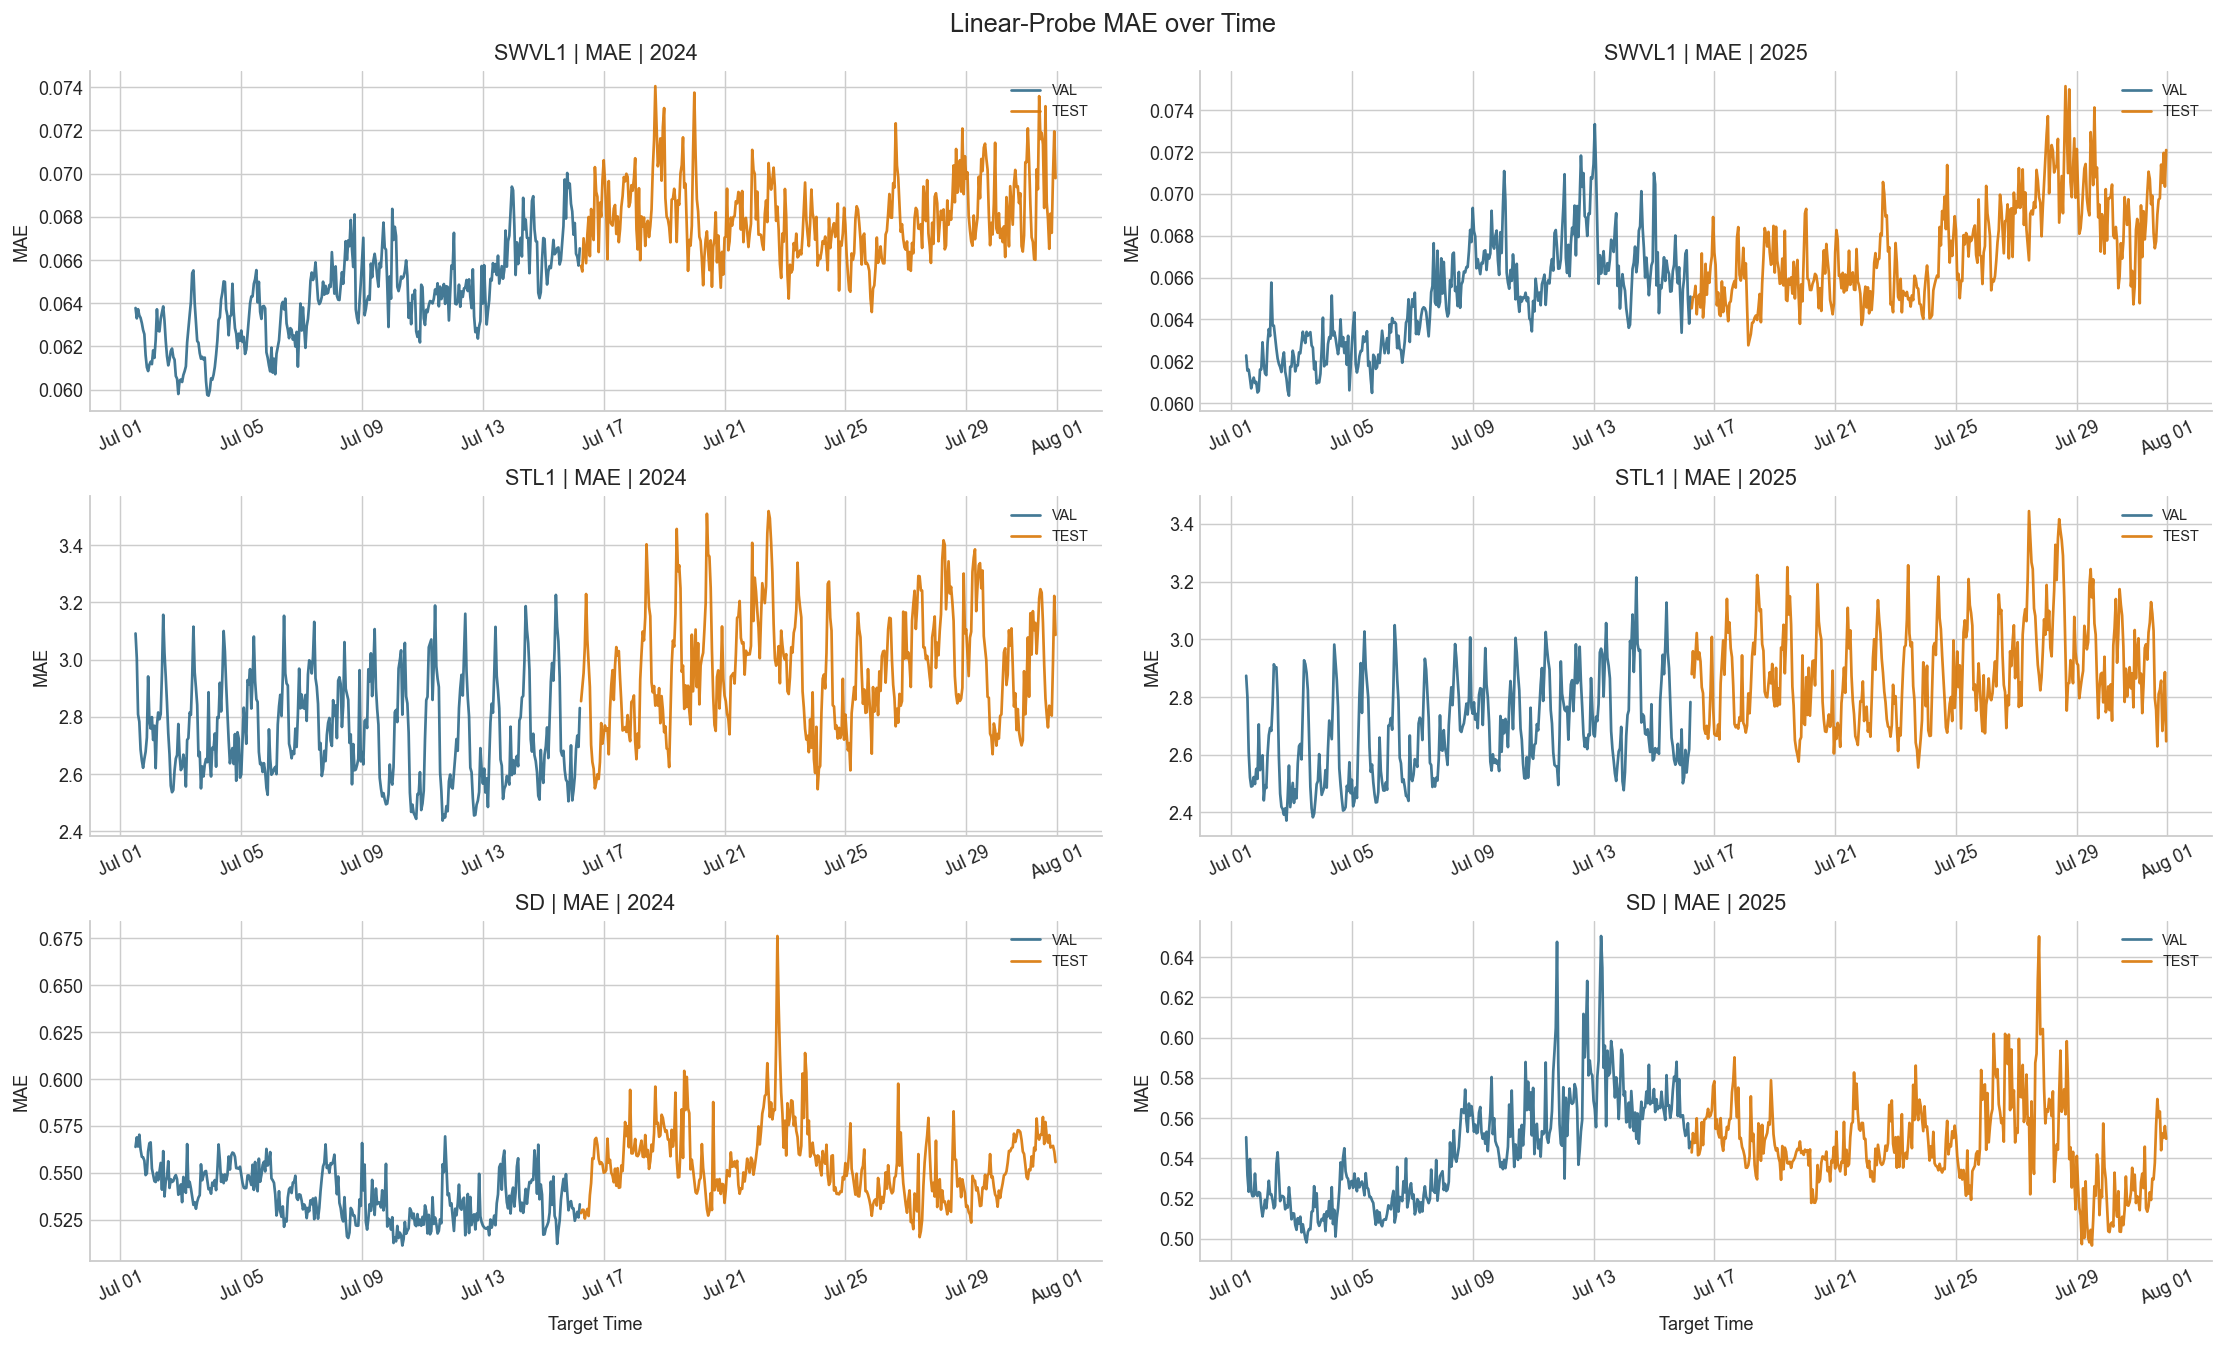

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/timeseries_mae.png


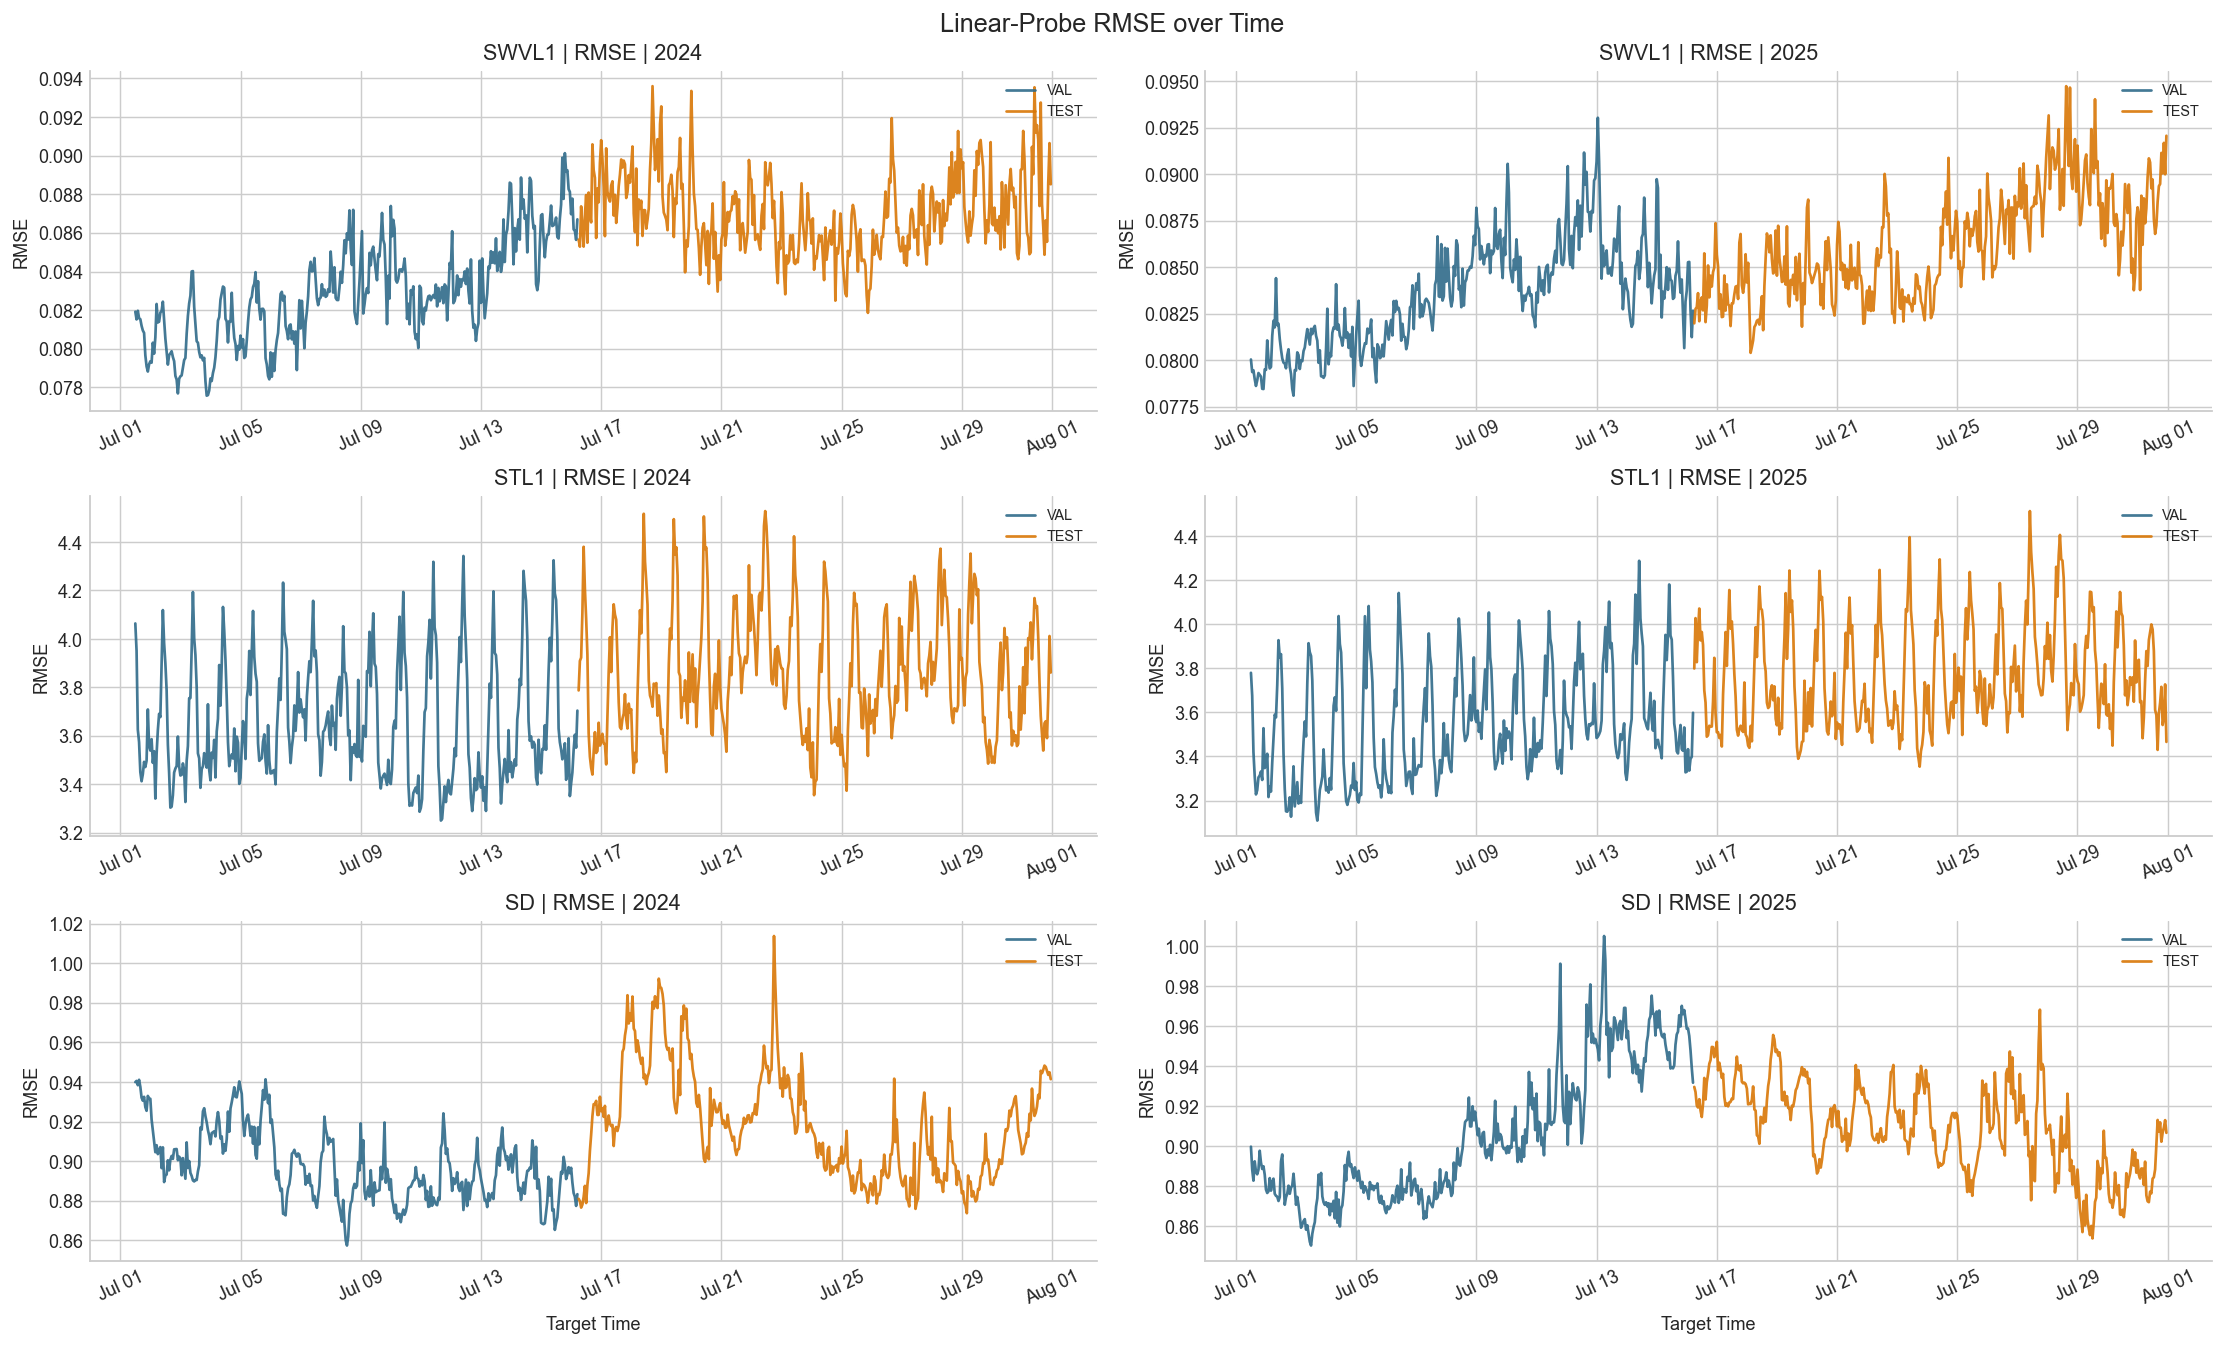

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/timeseries_rmse.png


mae                                    rmse            \
                      mean       std       min       max      mean       std   
split target_var                                                               
test  sd          0.551010  0.021076  0.496620  0.676316  0.913993  0.025176   
      stl1        2.930501  0.189045  2.546775  3.519206  3.811719  0.240724   
      swvl1       0.067672  0.002093  0.062762  0.075151  0.086583  0.002479   
val   sd          0.540951  0.021706  0.498151  0.650455  0.901748  0.027271   
      stl1        2.715384  0.173701  2.371682  3.226179  3.596127  0.246880   
      swvl1       0.064648  0.002327  0.059722  0.073333  0.083246  0.002693   

                                     mean_signed_error                      \
                       min       max              mean       std       min   
split target_var                                                             
test  sd          0.853836  1.013825          0.069622  0.085754 -0.168986   
      stl1        3.353852  4.527686          0.705694  0.568814 -1.009093   
      swvl1       0.080394  0.094742         -0.024955  0.008013 -0.047087   
val   sd          0.850294  1.005009          0.029923  0.101318 -0.263420   
      stl1        3.108713  4.342420          0.101691  0.532308 -1.410036   
      swvl1       0.077573  0.093043         -0.015129  0.009042 -0.041107   

                            
                       max  
split target_var            
test  sd          0.358785  
      stl1        2.304645  
      swvl1       0.000557  
val   sd          0.380088  
      stl1        1.446846  
      swvl1       0.014868

In [30]:
PER_SAMPLE_PATH = REPO_ROOT / 'results' / 'linear_probe' / 'eval_20260506' / 'per_sample_metrics.csv'
import matplotlib.dates as mdates

per_sample_df = pd.read_csv(PER_SAMPLE_PATH)
for col in ['target_time', 'source_time']:
    per_sample_df[col] = pd.to_datetime(per_sample_df[col])
per_sample_df['target_year'] = per_sample_df['target_time'].dt.year

ts_df = per_sample_df.sort_values(['target_var', 'split', 'target_time']).copy()
years = [2024, 2025]
line_styles = {
    'val': dict(color=MODEL_COLORS['Linear Probe'], linestyle='-', alpha=0.9, linewidth=1.5, label='VAL'),
    'test': dict(color='#D97706', linestyle='-', alpha=0.9, linewidth=1.5, label='TEST'),
}

for metric_name, ylabel in [('mae', 'MAE'), ('rmse', 'RMSE')]:
    fig, axes = plt.subplots(3, 2, figsize=(17, 10), sharex=False, constrained_layout=True)
    for row, variable in enumerate(variables):
        var_df = ts_df[ts_df['target_var'] == variable]
        for col, year in enumerate(years):
            ax = axes[row, col]
            year_df = var_df[var_df['target_year'] == year]
            for split, style in line_styles.items():
                split_df = year_df[year_df['split'] == split].sort_values('target_time')
                if split_df.empty:
                    continue
                ax.plot(split_df['target_time'], split_df[metric_name], **style)
            ax.set_title(f"{pretty_names[variable]} | {ylabel} | {year}")
            ax.set_ylabel(ylabel)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
            ax.tick_params(axis='x', rotation=25)
            ax.legend(frameon=False, loc='upper right', fontsize=8)

    for ax in axes[-1, :]:
        ax.set_xlabel('Target Time')
    fig.suptitle(f'Linear-Probe {ylabel} over Time', fontsize=14, y=1.02)
    save_path = FIGURE_DIR / f'timeseries_{metric_name}.png'
    fig.savefig(save_path, bbox_inches='tight')
    plt.show()
    print('Saved:', save_path)

time_summary = (
    ts_df.groupby(['split', 'target_var'])[['mae', 'rmse', 'mean_signed_error']]
    .agg(['mean', 'std', 'min', 'max'])
)
time_summary


**Figure 5. Linear-probe MAE and RMSE over target time, split by year.** Each curve shows land-aggregated error for one variable across the July 2024 or July 2025 evaluation window. `swvl1` shows mild seasonal drift, `sd` has episodic spikes consistent with sparse snow-sensitive regions, and `stl1` shows a repeated oscillatory pattern.

The repeated oscillation in STL1 is what motivates the next section: is it a synoptic pattern, or does soil-temperature error depends on the phase of the daily heating cycle?

## 5. Diurnal Structure in Probe Error

The time-series plots show a repeated oscillation in `stl1` error that is too regular to be explained only by seasonal drift or isolated weather events. Since soil temperature has a strong daily cycle, the natural next question is whether the probe’s error is systematically tied to target hour.

To test this, we collapse the per-sample metrics by UTC target hour and compute the mean MAE for each variable. This converts the previous time-series view into a phase-of-day view. If the oscillation in `stl1` is genuinely diurnal, it should remain visible after averaging across dates.

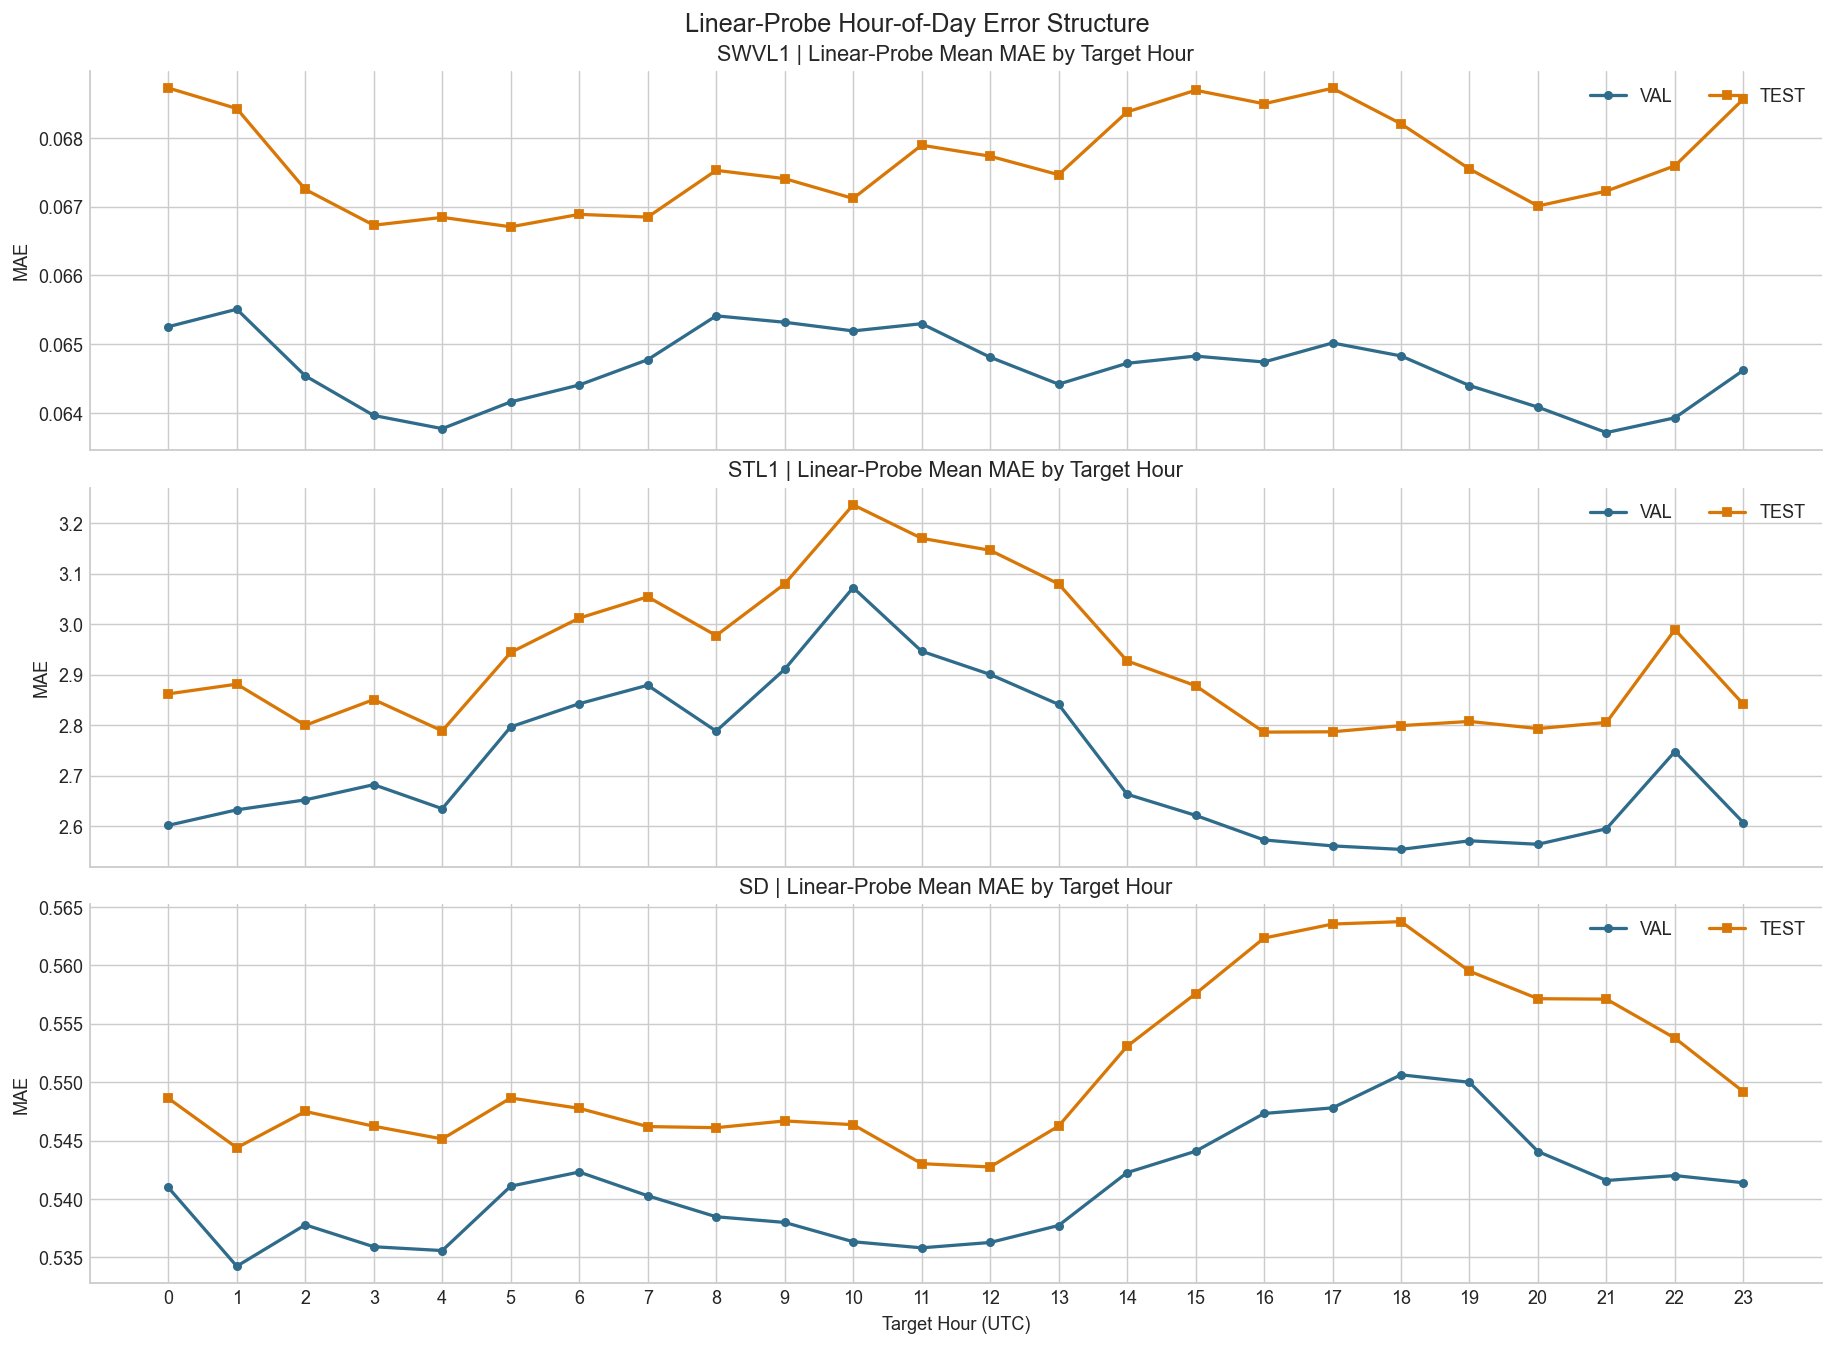

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/hour_of_day_mae_linear_probe.png


In [31]:
hourly_lp_df = ts_df.copy()
hourly_lp_df['hour'] = hourly_lp_df['target_time'].dt.hour
hourly_lp_mae = hourly_lp_df.groupby(['target_var', 'split', 'hour'], as_index=False)['mae'].mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
hours = np.arange(24)
for ax, variable in zip(axes, variables):
    sub = hourly_lp_mae[hourly_lp_mae['target_var'] == variable]
    for split, color, marker, label in [
        ('val', MODEL_COLORS['Linear Probe'], 'o', 'VAL'),
        ('test', '#D97706', 's', 'TEST'),
    ]:
        vals = sub[sub['split'] == split].set_index('hour').reindex(hours)['mae']
        if vals.notna().any():
            ax.plot(hours, vals.to_numpy(), label=label, color=color, marker=marker, markersize=4, linewidth=1.8)
    ax.set_title(f"{pretty_names[variable]} | Linear-Probe Mean MAE by Target Hour")
    ax.set_ylabel('MAE')
    ax.legend(frameon=False, ncol=2, loc='upper right')

axes[-1].set_xlabel('Target Hour (UTC)')
axes[-1].set_xticks(hours)
fig.suptitle('Linear-Probe Hour-of-Day Error Structure', fontsize=14, y=1.02)
save_path = FIGURE_DIR / 'hour_of_day_mae_linear_probe.png'
fig.savefig(save_path, bbox_inches='tight')
plt.show()
print('Saved:', save_path)


**Figure 6. Linear-probe MAE by UTC target hour.** `stl1` shows the clearest hour-of-day dependence: error rises sharply through the morning UTC hours, peaks around the period where the land surface is transitioning most quickly, and then falls later in the day. 

`swvl1` is comparatively flat by hour, while `sd` shows a weaker but visible hour-dependent pattern on the test split. This suggests that the linear probe struggles most when the target variable is changing rapidly rather than when it is near a slowly varying part of its daily cycle.

## 6. STL1 Hour-of-Day Baseline Check

The hour-of-day plot makes `stl1` the most interesting target for deeper temporal diagnosis. Unlike `swvl1`, which is dominated by slow short-horizon persistence, soil temperature changes substantially over the day. A model can therefore look good on average while still failing during the hours when the soil-temperature trajectory is steepest.

Hence, we now zoom in on test-set `stl1` and compare the linear probe against persistence and climatology by target hour. The comparison helps separate three sources of predictive power: persistence uses the recent state, climatology uses the average daily cycle, and the linear probe uses the frozen Aurora representation.

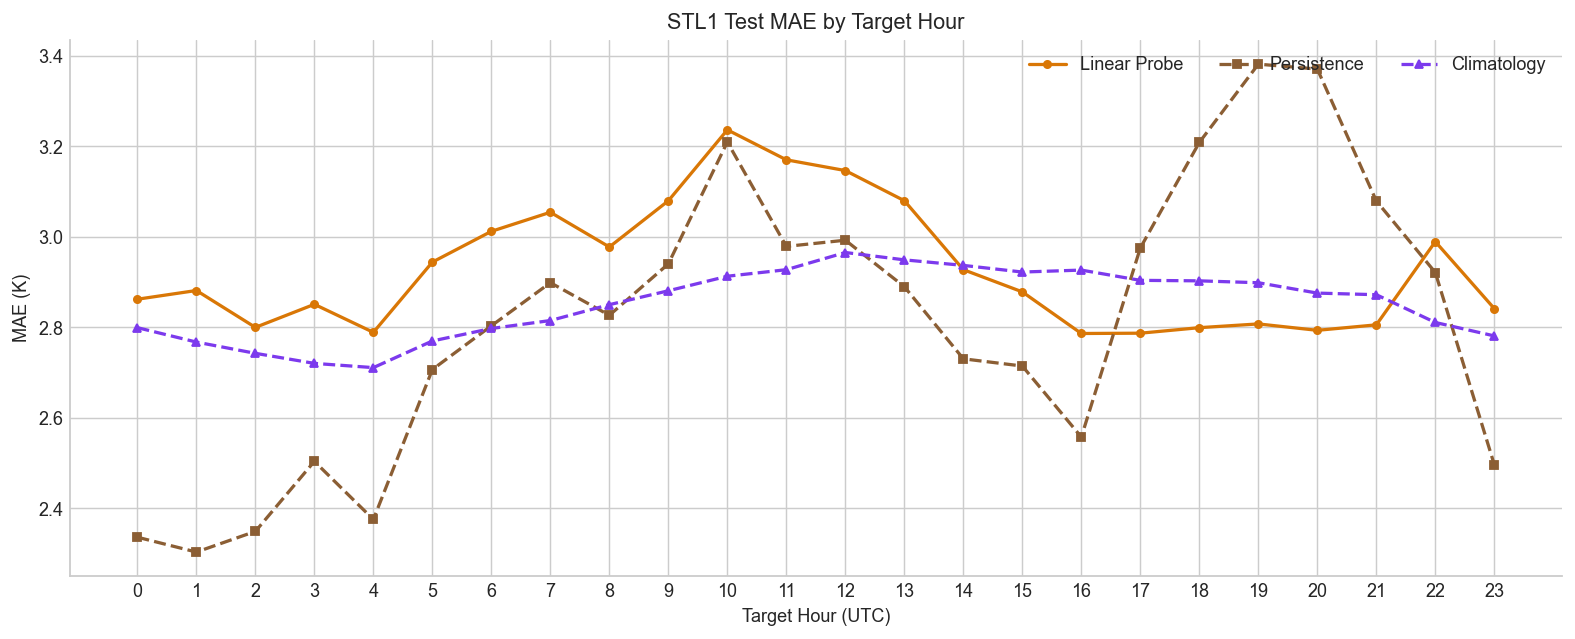

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/stl1_hour_of_day_mae_baseline_check.png


In [32]:
PERSISTENCE_PER_SAMPLE_PATH = REFERENCE_BASELINE_DIR / 'persistence' / 'per_sample_metrics.csv'
CLIMATOLOGY_PER_SAMPLE_PATH = REFERENCE_BASELINE_DIR / 'climatology' / 'per_sample_metrics.csv'

lp_test_hourly = ts_df[(ts_df['split'] == 'test') & (ts_df['target_var'] == 'stl1')].copy()
lp_test_hourly['model'] = 'Linear Probe'

persistence_per_sample_df = pd.read_csv(PERSISTENCE_PER_SAMPLE_PATH)
persistence_per_sample_df['model'] = 'Persistence'
climatology_per_sample_df = pd.read_csv(CLIMATOLOGY_PER_SAMPLE_PATH)
climatology_per_sample_df['model'] = 'Climatology'

baseline_hourly = pd.concat([persistence_per_sample_df, climatology_per_sample_df], ignore_index=True)
baseline_hourly = baseline_hourly[(baseline_hourly['split'] == 'test') & (baseline_hourly['target_var'] == 'stl1')].copy()

stl1_hourly_df = pd.concat([lp_test_hourly, baseline_hourly], ignore_index=True)
stl1_hourly_df['target_time'] = pd.to_datetime(stl1_hourly_df['target_time'])
stl1_hourly_df['hour'] = stl1_hourly_df['target_time'].dt.hour
hourly_mae = stl1_hourly_df.groupby(['model', 'hour'], as_index=False)['mae'].mean()

fig, ax = plt.subplots(figsize=(12, 4.8), constrained_layout=True)
hours = np.arange(24)
for model, color, linestyle, marker in [
    ('Linear Probe', '#D97706', '-', 'o'),
    ('Persistence', MODEL_COLORS['Persistence'], '--', 's'),
    ('Climatology', MODEL_COLORS['Climatology'], '--', '^'),
]:
    vals = hourly_mae[hourly_mae['model'] == model].set_index('hour').reindex(hours)['mae']
    ax.plot(hours, vals.to_numpy(), label=model, color=color, linestyle=linestyle, marker=marker, markersize=4, linewidth=1.8)

ax.set_title('STL1 Test MAE by Target Hour')
ax.set_xlabel('Target Hour (UTC)')
ax.set_ylabel('MAE (K)')
ax.set_xticks(hours)
ax.legend(frameon=False, ncol=3, loc='upper right')
save_path = FIGURE_DIR / 'stl1_hour_of_day_mae_baseline_check.png'
fig.savefig(save_path, bbox_inches='tight')
plt.show()
print('Saved:', save_path)


**Figure 7. Test-set `stl1` MAE by UTC target hour for the linear probe, persistence, and climatology.** Persistence is strongest during hours where soil temperature changes slowly, but its error increases sharply when the 6-hour target crosses a faster heating or cooling transition. Climatology is smoother because it captures the average daily cycle but ignores the current state. The linear probe is more stable than persistence across the day, but it still has a clear error peak around the difficult transition hours. This explains why aggregate 6-hour metrics can be misleading: persistence can win by exploiting short-term inertia even though it is not a robust rollout model.

### Temporal Observations

The temporal plots add an important observation to the aggregate results: the linear probe does not fail uniformly over time. For `swvl1`, the main pattern is slow drift through July, especially in the test windows, which suggests sensitivity to evolving surface-moisture regimes. For `sd`, the error is mostly quiet but has localized spikes, consistent with the fact that snow depth is sparse in summer and errors concentrate in snow-present regimes.

The most interesting temporal behavior is in `stl1`. Both the raw time-series curves and the hour-of-day aggregation show a clear diurnal structure. The probe performs worse during hours when soil temperature is changing more rapidly and better during more stable parts of the cycle. This is exactly the kind of pattern that aggregate MAE hides: the model can have a good average error while still having systematic weakness at particular phases of the physical process.

The baseline comparison clarifies why persistence must be interpreted carefully. At a single `t + 6h` horizon, persistence is a strong baseline because land variables often remain close to their current value. But that strength is partly an artifact of the evaluation design. In a rollout setting, repeatedly copying or weakly updating the previous state would likely accumulate error and fail to track changing conditions. Therefore, persistence beating a learned model on a one-step metric does not imply that it is the better forecasting mechanism.

## 7. Predicted-vs-Truth Calibration

The previous sections analyze error magnitude across variables, space, and time. The final diagnostic asks a different question: how are the predictions distributed relative to the true target values? These scatter plots use reservoir-subsampled land-pixel prediction/truth pairs from the validation and test evaluations.

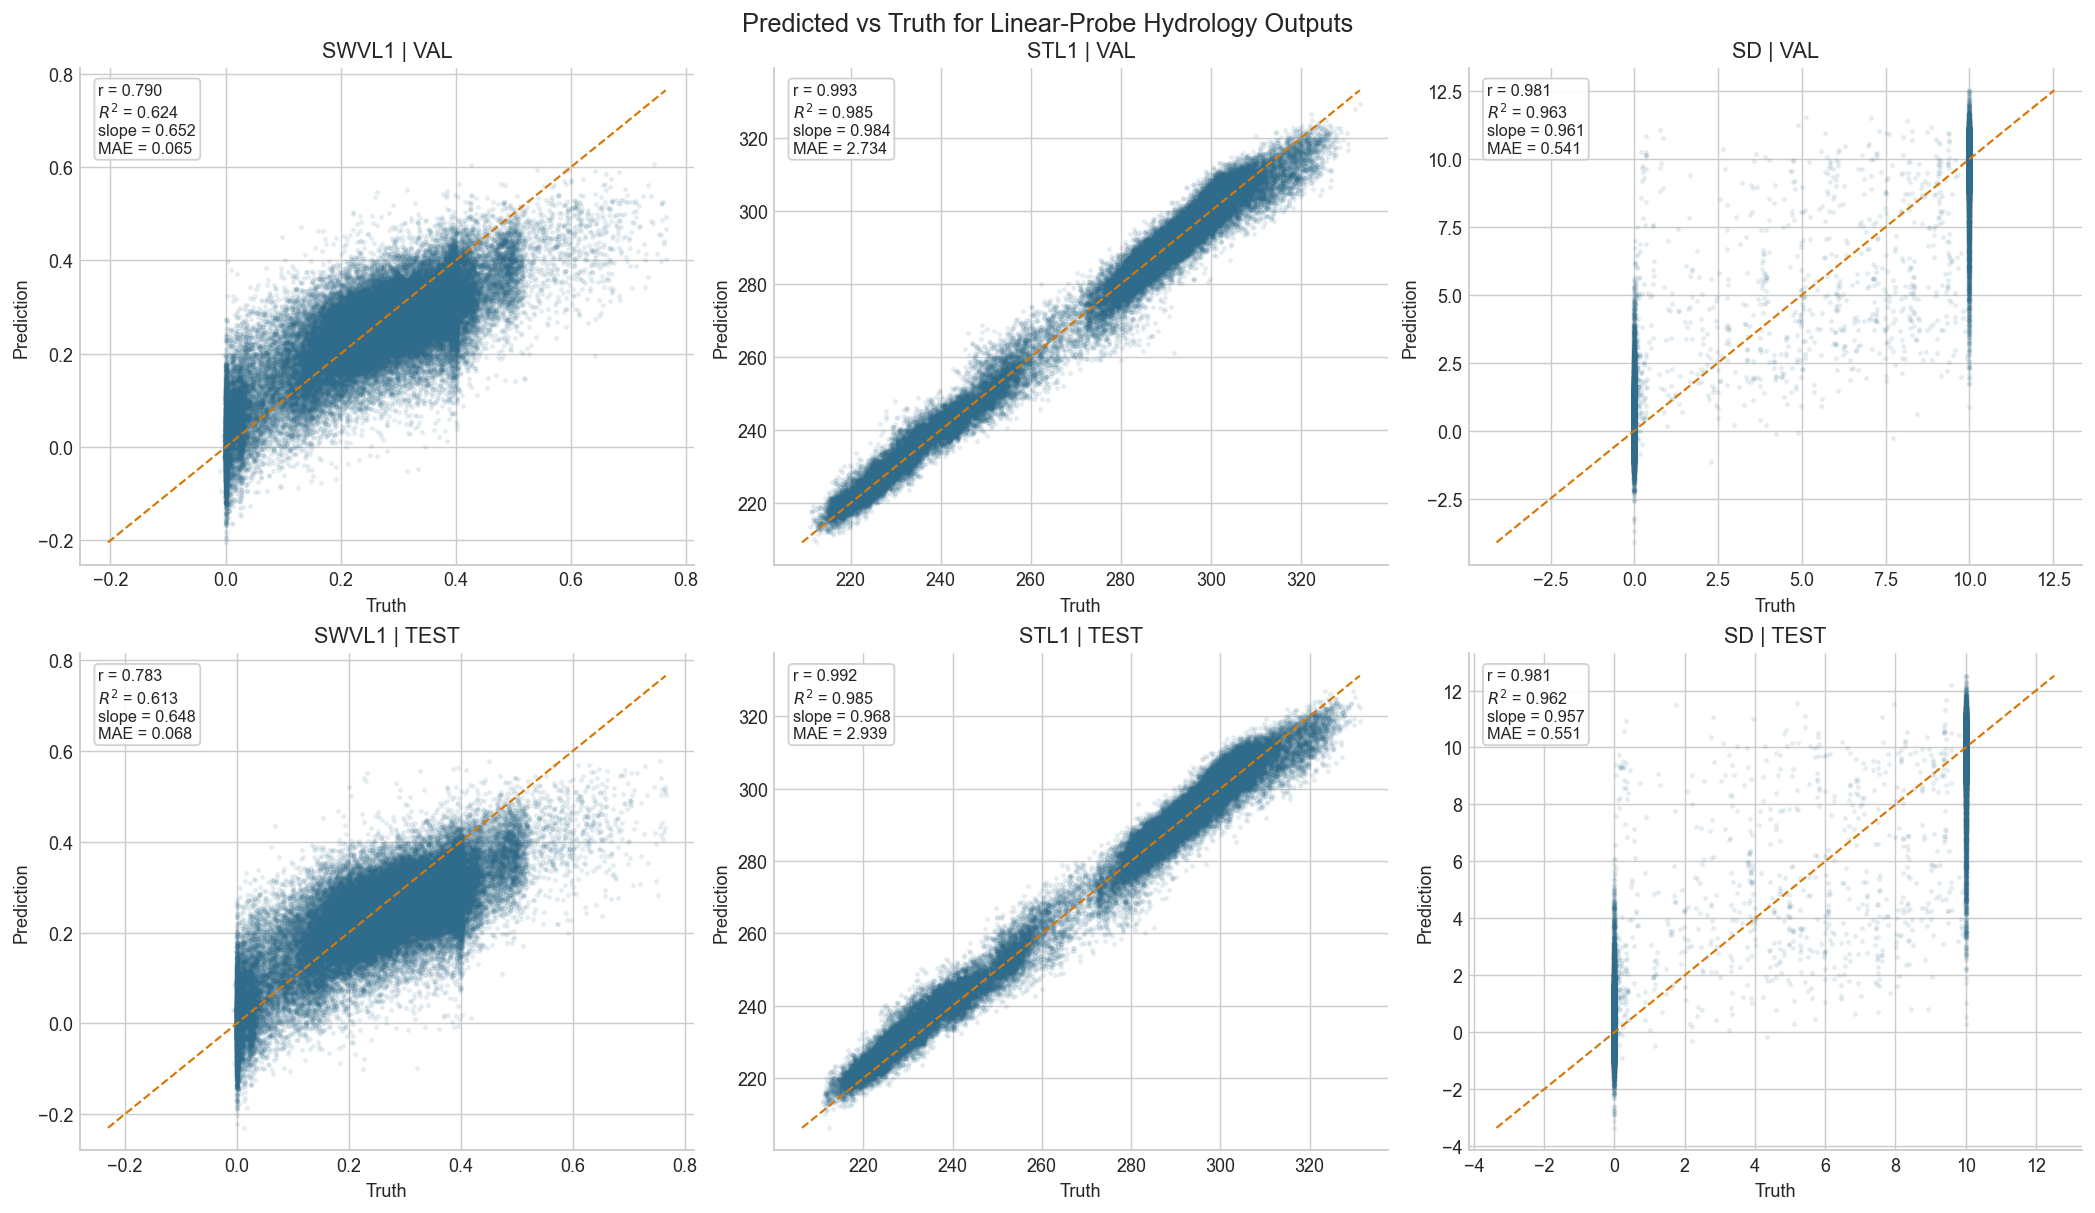

Saved: /Users/advitranawade/Penn Junior/CIS 7000/CIS-7000-Final-Project/results/linear_probe/figures/scatter_pred_vs_truth.png


In [33]:
import pickle
import zipfile

def load_scatter_payload(path):
    with zipfile.ZipFile(path, 'r') as zf:
        data_name = [name for name in zf.namelist() if name.endswith('data.pkl')][0]
        return pickle.loads(zf.read(data_name))

scatter_payloads = {
    'val': load_scatter_payload(REPO_ROOT / 'results' / 'linear_probe' / 'eval_20260506' / 'scatter_samples_val.pt'),
    'test': load_scatter_payload(REPO_ROOT / 'results' / 'linear_probe' / 'eval_20260506' / 'scatter_samples_test.pt'),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
for row, split in enumerate(['val', 'test']):
    for col, variable in enumerate(variables):
        ax = axes[row, col]
        truth = scatter_payloads[split][variable]['truth']
        pred = scatter_payloads[split][variable]['pred']

        ax.scatter(truth, pred, s=4, alpha=0.08, color='#2F6B8A', rasterized=True)
        lo = float(min(truth.min(), pred.min()))
        hi = float(max(truth.max(), pred.max()))
        ax.plot([lo, hi], [lo, hi], linestyle='--', linewidth=1.2, color='#D97706')

        corr = float(np.corrcoef(truth, pred)[0, 1])
        r2 = corr ** 2
        slope = float(np.polyfit(truth, pred, 1)[0])
        mae = float(np.mean(np.abs(pred - truth)))
        ax.text(
            0.03,
            0.97,
            f'r = {corr:.3f}\n$R^2$ = {r2:.3f}\nslope = {slope:.3f}\nMAE = {mae:.3f}',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='0.8', alpha=0.9),
        )

        ax.set_title(f"{pretty_names[variable]} | {split.upper()}")
        ax.set_xlabel('Truth')
        ax.set_ylabel('Prediction')

fig.suptitle('Predicted vs Truth for Linear-Probe Hydrology Outputs', fontsize=14, y=1.02)
save_path = FIGURE_DIR / 'scatter_pred_vs_truth.png'
fig.savefig(save_path, bbox_inches='tight')
plt.show()
print('Saved:', save_path)


**Figure 8. Predicted-versus-truth scatter plots for the linear probe on validation and test.** Each panel uses a subsampled set of land-pixel `(prediction, truth)` pairs and annotates correlation, $R^2$, slope, and MAE. 

`stl1` lies close to the identity line, indicating strong linear recoverability. `swvl1` shows meaningful correlation but clear dynamic-range compression. `sd` has a highly structured, zero-inflated distribution, so its scatter should be interpreted as a regime-separation problem rather than as an ordinary Gaussian regression cloud.

### Calibration

The calibration plots reinforce the variable-specific story. `stl1` is the strongest linearly-decodable result, with its predictions closely following the identity line. This suggests that soil temperature is already strongly represented in Aurora’s frozen latent space, with the remaining error coming largely from calibration and phase-dependent temporal effects.

`swvl1` is recoverable but visibly compressed. The probe tends to overpredict very dry values and underpredict wetter values, producing a slope well below one. This means the frozen representation contains soil-moisture signal, but the linear head does not fully recover the target’s dynamic range. That observation is consistent with the normalized error comparison, where `swvl1` is the hardest target for the linear probe.

`sd` requires a different interpretation. Because July snow depth is heavily zero-inflated, many points lie at or near zero truth, while a smaller number occupy high-snow regimes. The vertical structure in the scatter is therefore not just noise; it reflects the target distribution. The probe appears to separate broad snow regimes reasonably well, but it has calibration issues near zero and sometimes predicts physically invalid negative values. This suggests that a more constrained head or target transformation could be useful for snow depth, even without changing the main model architecture.

Across all three variables, validation and test scatter plots look very similar. This supports the broader conclusion that the linear probe is not overfitting the validation window. Its limitations are systematic: dynamic-range compression for `swvl1`, diurnal/transition errors for `stl1`, and zero-inflated calibration issues for `sd`.

## 8. Takeaways

The results support a consistent interpretation of Aurora’s transfer behavior. The frozen Aurora representation already contains meaningful information about the out-of-distribution land-surface targets, because a strict linear probe can recover nontrivial signal for `swvl1`, `stl1`, and `sd`. However, the quality of that recovery is variable-dependent. `stl1` is the clearest case of strong linear recoverability, `swvl1` is recoverable but compressed and substantially harder, and `sd` is dominated by sparse-regime and calibration issues.

The Stage 1 fine-tuned model improves substantially over the frozen linear probe, which suggests that adaptation is doing more than simply attaching a new readout layer. At the same time, the reference baselines show why this task must be interpreted carefully. Since the forecast horizon is only six hours, persistence can be extremely competitive for slowly changing land variables.

While Aurora’s pretrained latent space already carries land-surface information, the fine-tuned model shows that task-specific adaptation improves that information or makes it more accessible. The temporal and spatial diagnostics show where the frozen readout fails: broad soil-moisture dynamic-range compression, regional soil-temperature bias, diurnal transition errors, and sparse snow-depth calibration. Together, these results motivate evaluating future models not only on one-step MAE, but also on rollout behavior, regime-specific errors, and physically constrained calibration.